# Charging Gaps and Underserved Communities

## Goal

Measure approximate proximity from each block group to existing public charging, combine accessibility with market-demand and public-access-need indicators, and identify relative priority areas for further investigation.

> This is a screening analysis. Straight-line distance from a block-group representative point is not a drive-time service area, and a high score is not yet a final station recommendation.

## Context & Methods

### Key assumptions

- Each AFDC station ID is counted once even when the charging-unit file contains multiple rows for that station.
- Distance is measured in an equal-area projected coordinate system and converted to approximate miles.
- Gap scores are relative percentiles within the seven-county study area.
- Market and community-access needs remain separate to avoid treating income as a proxy for equity.
- The highest-priority quartile is a screening threshold, not a claim that exactly 25% of communities require stations.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(r"C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability")
SPATIAL_DIR = PROJECT_ROOT / "outputs" / "spatial"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
MAP_DIR = PROJECT_ROOT / "maps"
for folder in [SPATIAL_DIR, TABLE_DIR, MAP_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

demand_path = SPATIAL_DIR / "acs_ev_demand_block_groups.gpkg"
station_path = SPATIAL_DIR / "existing_ev_charging_units.gpkg"
if not demand_path.exists():
    raise FileNotFoundError("Run notebook 04 first to create ACS demand block groups.")
if not station_path.exists():
    raise FileNotFoundError("Run notebook 03 first to create the existing station layer.")

demand = gpd.read_file(demand_path, layer="ev_demand")
charging_units = gpd.read_file(station_path, layer="charging_units")

for field in ["EV Level2 EVSE Num", "EV DC Fast Count"]:
    charging_units[field] = pd.to_numeric(charging_units.get(field, 0), errors="coerce").fillna(0)

stations = charging_units.sort_values("ID").drop_duplicates(subset="ID").copy()
dc_fast_stations = stations.loc[stations["EV DC Fast Count"] > 0].copy()
assert stations["ID"].is_unique
assert not dc_fast_stations.empty, "The study area contains no DC fast stations in the AFDC extract."

print(f"Block groups: {len(demand):,}")
print(f"Unique public stations: {len(stations):,}")
print(f"Stations with DC fast charging: {len(dc_fast_stations):,}")

Block groups: 926
Unique public stations: 272
Stations with DC fast charging: 57


## Data

### 1. Calculate approximate distance to the nearest station

In [2]:
DISTANCE_CRS = "EPSG:5070"
METERS_PER_MILE = 1609.344

demand_projected = demand.to_crs(DISTANCE_CRS)
centers = demand_projected.copy()
centers["geometry"] = demand_projected.geometry.representative_point()
stations_projected = stations.to_crs(DISTANCE_CRS)
dc_projected = dc_fast_stations.to_crs(DISTANCE_CRS)

nearest_any = gpd.sjoin_nearest(
    centers[["GEOID", "geometry"]],
    stations_projected[["ID", "Station Name", "geometry"]],
    how="left", distance_col="nearest_station_meters",
).sort_values("nearest_station_meters").drop_duplicates("GEOID")

nearest_dc = gpd.sjoin_nearest(
    centers[["GEOID", "geometry"]],
    dc_projected[["ID", "Station Name", "geometry"]],
    how="left", distance_col="nearest_dc_fast_meters",
).sort_values("nearest_dc_fast_meters").drop_duplicates("GEOID")

distance_table = nearest_any[["GEOID", "nearest_station_meters"]].merge(
    nearest_dc[["GEOID", "nearest_dc_fast_meters"]], on="GEOID", validate="one_to_one"
)
gap = demand.merge(distance_table, on="GEOID", validate="one_to_one")
gap["nearest_station_miles"] = gap["nearest_station_meters"] / METERS_PER_MILE
gap["nearest_dc_fast_miles"] = gap["nearest_dc_fast_meters"] / METERS_PER_MILE

display(gap[["nearest_station_miles", "nearest_dc_fast_miles"]].describe().round(2))

,nearest_station_miles,nearest_dc_fast_miles
count,926.00,926.00
mean,2.08,2.95
std,2.09,2.36
min,0.04,0.11
25%,0.86,1.34
50%,1.46,2.38
75%,2.47,3.84
max,16.11,17.26


## Results

### 2. Calculate relative gap scores and priority tiers

Block groups without a published median-household-income estimate receive the neutral 50th-percentile income component. This keeps them in the screening while avoiding an unsupported high- or low-income assumption.

Block groups without a published median-household-income estimate receive the neutral 50th-percentile income component. This keeps them in the screening while avoiding an unsupported high- or low-income assumption.

In [3]:
def percentile(series):
    return series.rank(pct=True, method="average")

gap["station_distance_percentile"] = percentile(gap["nearest_station_miles"])
gap["dc_distance_percentile"] = percentile(gap["nearest_dc_fast_miles"])
# A missing published median income receives a neutral percentile; no dollar value is imputed.
gap["income_percentile"] = percentile(gap["median_household_income"]).fillna(0.50)
# A missing published median income receives a neutral percentile; no dollar value is imputed.
gap["income_percentile"] = percentile(gap["median_household_income"]).fillna(0.50)

gap["market_demand_index"] = 100 * (
    0.45 * percentile(gap["population_density"]) +
    0.30 * percentile(gap["household_density"]) +
    0.25 * gap["income_percentile"]
)

gap["market_gap_score"] = (
    0.60 * 100 * (
        0.45 * percentile(gap["population_density"]) +
        0.30 * percentile(gap["household_density"]) +
        0.25 * gap["income_percentile"]
    ) +
    0.40 * 100 * gap["station_distance_percentile"]
)
gap["community_gap_score"] = (
    0.60 * gap["public_access_need_index"] +
    0.40 * 100 * gap["station_distance_percentile"]
)
gap["dc_fast_gap_score"] = (
    0.50 * gap["market_demand_index"] +
    0.50 * 100 * gap["dc_distance_percentile"]
)

for score in ["market_gap_score", "community_gap_score", "dc_fast_gap_score"]:
    threshold = gap[score].quantile(0.75)
    gap[score.replace("_score", "_priority")] = np.where(gap[score] >= threshold, "High relative priority", "Other")

gap.to_file(SPATIAL_DIR / "charging_gap_block_groups.gpkg", layer="charging_gaps", driver="GPKG")

ranked = gap[[
    "GEOID", "county_name", "population", "median_household_income",
    "nearest_station_miles", "nearest_dc_fast_miles",
    "market_demand_index", "public_access_need_index",
    "market_gap_score", "community_gap_score", "dc_fast_gap_score",
]].sort_values("community_gap_score", ascending=False)
ranked.to_csv(TABLE_DIR / "charging_gap_block_group_ranking.csv", index=False)
display(ranked.head(20).round(2))

,GEOID,county_name,population,median_household_income,nearest_station_miles,nearest_dc_fast_miles,market_demand_index,public_access_need_index,market_gap_score,community_gap_score,dc_fast_gap_score
881,132971103021,Walton,1906,34021.0,10.37,10.59,32.38,82.56,58.91,89.02,65.44
886,132971107022,Walton,1727,44612.0,9.48,9.73,50.63,79.54,69.56,86.90,74.07
583,131350503311,Gwinnett,1546,63295.0,2.53,2.53,73.72,91.40,74.73,85.34,63.86
778,131350504411,Gwinnett,1264,63000.0,2.18,2.73,74.32,96.31,72.07,85.26,66.16
903,130591507013,Clarke,2015,60051.0,2.19,3.39,75.46,91.58,72.83,82.51,72.12
514,131350505393,Gwinnett,2165,56358.0,2.21,2.29,74.80,90.44,72.61,81.99,61.32
885,132971104001,Walton,3026,33750.0,8.15,8.17,25.99,70.79,54.47,81.35,60.89
895,132971103012,Walton,1688,49519.0,10.24,10.29,33.13,69.03,59.31,80.86,65.59
508,131350505502,Gwinnett,1677,79464.0,3.47,3.47,69.14,75.72,76.17,80.12,69.67
916,130591504003,Clarke,584,33717.0,2.47,2.47,38.69,83.39,53.24,80.06,45.64


### 3. Test sensitivity to the demand-versus-distance weights

The baseline uses 60% need and 40% distance. Two alternative scenarios test whether the top-priority group remains similar when the weights change.

In [4]:
baseline = gap["community_gap_score"]
gap["community_gap_equal_weights"] = (
    0.50 * gap["public_access_need_index"] + 0.50 * 100 * gap["station_distance_percentile"]
)
gap["community_gap_need_focused"] = (
    0.70 * gap["public_access_need_index"] + 0.30 * 100 * gap["station_distance_percentile"]
)

def top_quartile_ids(series):
    return set(gap.loc[series >= series.quantile(0.75), "GEOID"])

baseline_ids = top_quartile_ids(baseline)
sensitivity = pd.DataFrame({
    "scenario": ["50% need / 50% distance", "70% need / 30% distance"],
    "top_quartile_overlap_with_baseline": [
        len(baseline_ids & top_quartile_ids(gap["community_gap_equal_weights"])) / len(baseline_ids),
        len(baseline_ids & top_quartile_ids(gap["community_gap_need_focused"])) / len(baseline_ids),
    ],
})
sensitivity.to_csv(TABLE_DIR / "charging_gap_weight_sensitivity.csv", index=False)
display(sensitivity.style.format({"top_quartile_overlap_with_baseline": "{:.1%}"}))

,scenario,top_quartile_overlap_with_baseline
0,50% need / 50% distance,76.7%
1,70% need / 30% distance,79.7%


### 4. Map market and community charging gaps

Both panels use the same 0–100 scale. Existing stations are shown as white circles with dark outlines to provide geographic context without competing with the gap surface.

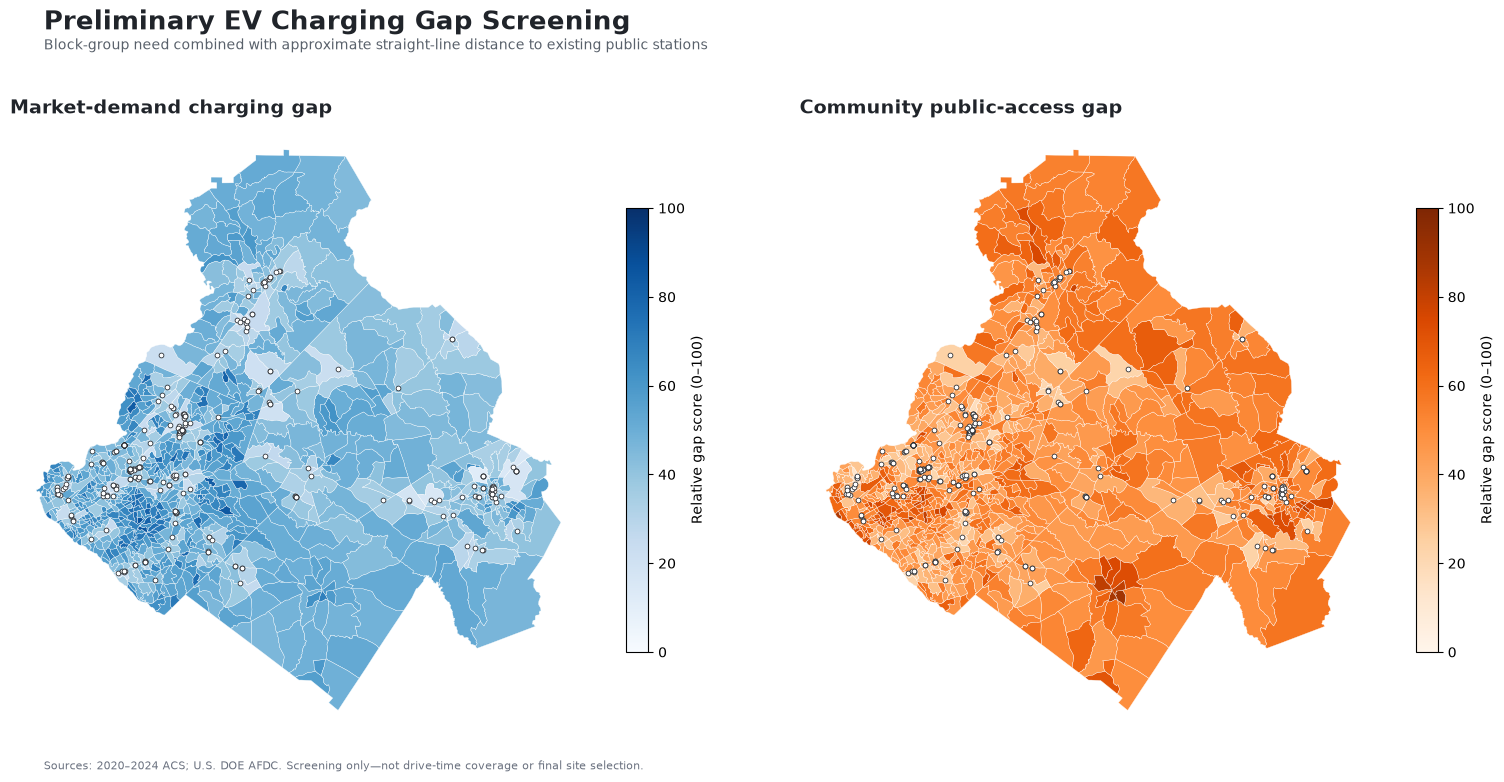

Saved: C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\maps\preliminary_charging_gap_screening.png


In [5]:
gap_map = gap.to_crs("EPSG:4326")
station_map = stations.to_crs(gap_map.crs)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), facecolor="white")
panels = [
    ("market_gap_score", "Market-demand charging gap", "Blues"),
    ("community_gap_score", "Community public-access gap", "Oranges"),
]

for ax, (field, title, cmap) in zip(axes, panels):
    gap_map.plot(
        column=field, ax=ax, cmap=cmap, vmin=0, vmax=100,
        edgecolor="#FFFFFF", linewidth=0.25, legend=True,
        legend_kwds={"label": "Relative gap score (0–100)", "shrink": 0.72},
    )
    station_map.plot(ax=ax, facecolor="white", edgecolor="#20242A", marker="o", markersize=12, linewidth=0.55)
    ax.set_title(title, loc="left", fontsize=14, weight="bold", color="#20242A")
    ax.set_axis_off()

fig.suptitle("Preliminary EV Charging Gap Screening", x=0.06, ha="left", fontsize=19, weight="bold", color="#20242A")
fig.text(0.06, 0.93, "Block-group need combined with approximate straight-line distance to existing public stations", fontsize=10, color="#59616B")
fig.text(0.06, 0.03, "Sources: 2020–2024 ACS; U.S. DOE AFDC. Screening only—not drive-time coverage or final site selection.", fontsize=8, color="#6B7280")
plt.tight_layout(rect=[0, 0.05, 1, 0.91])

map_path = MAP_DIR / "preliminary_charging_gap_screening.png"
fig.savefig(map_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", map_path)

## Validation

These checks verify grain, join coverage, distance units, score bounds, output completeness, and sensitivity reporting.

In [6]:
assert gap["GEOID"].is_unique, "Block-group grain was duplicated."
assert len(gap) == len(demand), "The distance join dropped or multiplied block groups."
assert gap[["nearest_station_miles", "nearest_dc_fast_miles"]].notna().all().all()
assert (gap[["nearest_station_miles", "nearest_dc_fast_miles"]] >= 0).all().all()
assert gap[["market_gap_score", "community_gap_score", "dc_fast_gap_score"]].notna().all().all()
assert gap[["market_gap_score", "community_gap_score", "dc_fast_gap_score"]].notna().all().all()
assert gap[["market_gap_score", "community_gap_score", "dc_fast_gap_score"]].apply(lambda col: col.dropna().between(0, 100).all()).all()
assert sensitivity["top_quartile_overlap_with_baseline"].between(0, 1).all()

expected_outputs = [
    SPATIAL_DIR / "charging_gap_block_groups.gpkg",
    TABLE_DIR / "charging_gap_block_group_ranking.csv",
    TABLE_DIR / "charging_gap_weight_sensitivity.csv",
    MAP_DIR / "preliminary_charging_gap_screening.png",
]
assert all(path.exists() for path in expected_outputs)

print("All grain, join, calculation, and output checks passed.")
print("Validation status: Share with caveats until drive-time accessibility and traffic demand are added.")

All grain, join, calculation, and output checks passed.
Validation status: Share with caveats until drive-time accessibility and traffic demand are added.


## Takeaways and Next Steps

After execution, use the ranked table and paired maps to inspect candidate gap areas—not to declare final sites. Next, add interstate and major-road proximity plus Georgia DOT traffic counts for the DC-fast corridor model.